# Assignment 3

In [1]:
# Importing libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [2]:
# Loading the data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# reshape for CNN
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Building the model
fc_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compiling the model
fc_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training the model
fc_history = fc_model.fit(
    x_train, y_train,
    epochs=8,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8640 - loss: 0.4735 - val_accuracy: 0.9557 - val_loss: 0.1545
Epoch 2/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9586 - loss: 0.1355 - val_accuracy: 0.9645 - val_loss: 0.1145
Epoch 3/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9735 - loss: 0.0909 - val_accuracy: 0.9715 - val_loss: 0.1015
Epoch 4/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9808 - loss: 0.0649 - val_accuracy: 0.9684 - val_loss: 0.1078
Epoch 5/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9849 - loss: 0.0512 - val_accuracy: 0.9743 - val_loss: 0.0881
Epoch 6/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9892 - loss: 0.0372 - val_accuracy: 0.9733 - val_loss: 0.0923
Epoch 7/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9925 - loss: 0.0274 - val_accuracy: 0.9747 - val_loss: 0.0867
Epoch 8/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9934 - loss: 0.0230 - val_acc

In [4]:
# Building the CNN
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

# Compiling the model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training the model
cnn_history = cnn_model.fit(
    x_train_cnn, y_train,
    epochs=8,
    validation_split=0.2
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8743 - loss: 0.4528 - val_accuracy: 0.9712 - val_loss: 0.1017
Epoch 2/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9737 - loss: 0.0939 - val_accuracy: 0.9766 - val_loss: 0.0803
Epoch 3/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9808 - loss: 0.0660 - val_accuracy: 0.9785 - val_loss: 0.0726
Epoch 4/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9863 - loss: 0.0479 - val_accuracy: 0.9797 - val_loss: 0.0690
Epoch 5/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9857 - loss: 0.0438 - val_accuracy: 0.9759 - val_loss: 0.0824
Epoch 6/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9880 - loss: 0.0381 - val_accuracy: 0.9806 - val_loss: 0.0654
Epoch 7/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9897 - loss: 0.0328 - val_accuracy: 0.9797 - val_loss: 0.0674
Epoch 8/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9917 - loss: 0

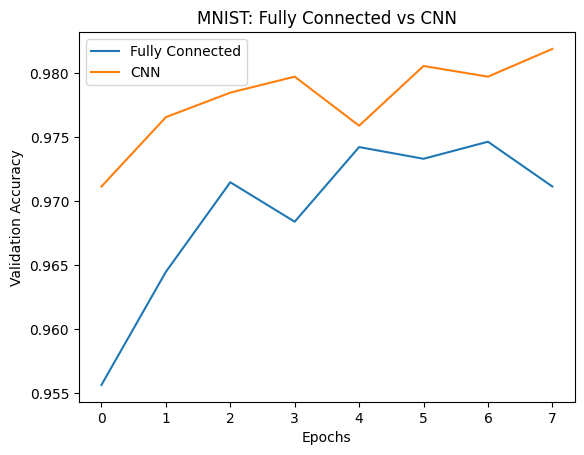

In [5]:
# plot accuracy
plt.plot(fc_history.history['val_accuracy'], label='Fully Connected')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('MNIST: Fully Connected vs CNN')
plt.legend()
plt.show()

In [6]:
# final accuracy
fc_acc = fc_model.evaluate(x_test, y_test, verbose=0)[1]
cnn_acc = cnn_model.evaluate(x_test_cnn, y_test, verbose=0)[1]

print("Fully Connected Test Accuracy:", fc_acc)
print("CNN Test Accuracy:", cnn_acc)


Fully Connected Test Accuracy: 0.9735999703407288
CNN Test Accuracy: 0.9839000105857849


## Conclusion
In this assignment, we implemented and compared two neural network architectures, a fully connected (dense) network and a convolutional neural network (CNN), on the MNIST dataset of handwritten digits. Both models were able to learn from the training data and achieve good validation accuracy. However, the CNN consistently outperformed the fully connected network in both validation and test accuracy. This demonstrates the strength of CNNs in handling image data, as their convolutional layers can effectively capture spatial patterns and local features, which fully connected networks struggle with. Overall, our results highlight that while fully connected networks can solve simpler tasks, CNNs are better suited for image recognition problems like digit classification.